## Gather Sense of Our Data:
Except for the <b>transaction</b> and <b>amount</b> we don't know what the other columns are (due to privacy reasons). The only thing we know is that those columns that are unknown have been scaled already.

<h3>Summary:</h3>
<ul>
<li>The transaction amount is relatively <b>small</b>. The mean of all the mounts made is approximately USD 88.
</li>
<li>There are no <b>"Null"</b> values, so we don't have to work on ways to replace values.
</li>
<li>Most of the transactions were <b>Non-Fraud</b>(99.83%) of the time, while <b>Fraud</b> transactions occurs (0.17%) of the time.
</li>
</ul>

<h3>Feature Technicalities: </h3>
<ul>
<li> <b>PCA Transformation: </b> The description of the data says that all the features went through a PCA transformation <b>(Except for time and amount)</b>.
</li>
<li> <b>Scaling: </b> Keep in mind that in order to implement a PCA transformation, features need to be previously scaled.
</li>
</ul>

In [63]:
import pandas
from pathlib import Path

ROOT_DIR = Path.cwd().parent
SRC = ROOT_DIR / 'data' / 'creditcard.csv'

df = pandas.read_csv(SRC)

In [10]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [25]:
# Check for missing values
df.isnull().sum().max()

0

In [64]:
# Creating target variable distribution dataframe

df_target = df['Class']
df_target_plot = df_target.value_counts().to_frame()

df_target_plot['Percentage'] = round((df_target_plot['count'] / len(df)) * 100, 2)
print(df_target_plot)

        count  Percentage
Class                    
0      284315       99.83
1         492        0.17


**Note** Notice how imbalanced is our dataset! If we use this dataframe as the base for our predictive models, our algorithms will probably overfit since it will 'assume' that most transactions are not fraud.

In [65]:
import numpy as np

def summarize_by_class(col):
    g = df.groupby("Class")[col]
    out = g.agg(["count","mean","median","min","max"])
    out["p95"] = g.quantile(0.95)
    out["p99"] = g.quantile(0.99)
    return out

print(summarize_by_class("Amount"))
print(summarize_by_class("Time"))

        count        mean  median  min       max      p95        p99
Class                                                               
0      284315   88.291022   22.00  0.0  25691.16  364.409  1016.9664
1         492  122.211321    9.25  0.0   2125.87  640.905  1357.4279
        count          mean   median    min       max        p95        p99
Class                                                                      
0      284315  94838.202258  84711.0    0.0  172792.0  164149.30  170564.00
1         492  80746.806911  75568.5  406.0  170348.0  156696.25  167500.36


C:\Users\User\AppData\Local\Temp\ipykernel_20404\3051152105.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



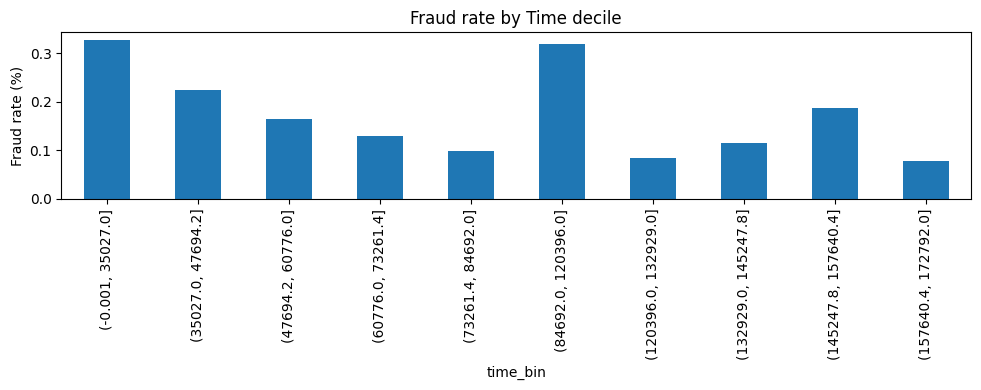

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
df_sorted = df.sort_values("Time")
df_sorted["time_bin"] = pd.qcut(df_sorted["Time"], q=10, duplicates="drop")

summary = df_sorted.groupby("time_bin")["Class"].mean() * 100

plt.figure(figsize=(10,4))
summary.plot(kind="bar")
plt.ylabel("Fraud rate (%)")
plt.title("Fraud rate by Time decile")
plt.tight_layout()
plt.show()

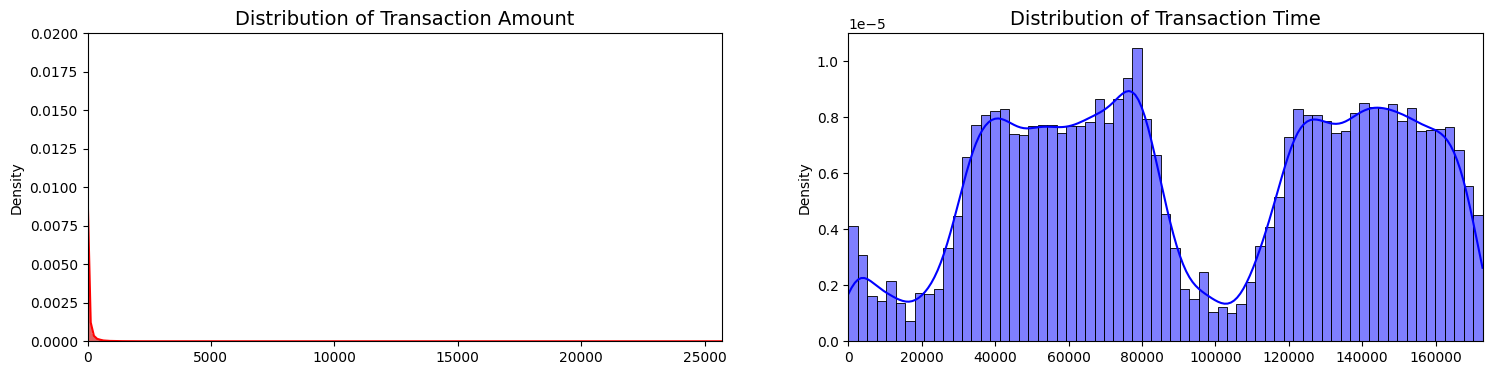

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(18, 4))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.histplot(amount_val, ax=ax[0], color='r', kde=True, stat='density')
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])
ax[0].set_ylim([0, 0.02])

sns.histplot(time_val, ax=ax[1], color='b', kde=True, stat="density")
ax[1].set_title("Distribution of Transaction Time", fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])

plt.show()

<h2> Scaling </h2>
In this phase of our kernel, we will first scale the columns comprise of <b>Time</b> and <b>Amount</b>. Time and Amount should be scaled as the other columns.
To choose which kind of scaling technique, you should look at the distribution of the data above.
<ul>
<li>
The Transaction amount has outlier issue, so Robust scaler would fit it best.
</li>
<li>
The Transaction time is bimodel distribution, since it's not gaussion, Robust scaler would fit better.
</li>
</ul>

In [38]:
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

# Reshape is needed if scaling a single column
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Drop original columns
df.drop(['Time','Amount'], axis=1, inplace=True)

In [45]:
cols = df.columns.tolist()
front = ["scaled_amount", "scaled_time"]

# keep front columns first, then the rest (excluding duplicates)
df = df[front + [c for c in cols if c not in front]]
df[['scaled_amount', 'scaled_time']].head()

,scaled_amount,scaled_time
0,1.783274,-0.994983
1,-0.269825,-0.994983
2,4.983721,-0.994972
3,1.418291,-0.994972
4,0.670579,-0.994960


In [46]:
import numpy as np
from sklearn.model_selection import train_test_split

# Features/labels
X = df.drop("Class", axis=1)
y = df["Class"]

# Stratified split keeps the same 0/1 ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% test
    random_state=42,        # reproducible
    stratify=y              # <-- the key for imbalanced labels
)

def show_dist(name, labels):
    unique, counts = np.unique(labels, return_counts=True)
    total = counts.sum()
    ratios = counts / total
    print(f"{name}: n={total}")
    for u, c, r in zip(unique, counts, ratios):
        print(f"  Class {u}: {c} ({r*100:.4f}%)")
    print()

show_dist("Full", y.values)
show_dist("Train", y_train.values)
show_dist("Test", y_test.values)


Full: n=284807
  Class 0: 284315 (99.8273%)
  Class 1: 492 (0.1727%)

Train: n=227845
  Class 0: 227451 (99.8271%)
  Class 1: 394 (0.1729%)

Test: n=56962
  Class 0: 56864 (99.8280%)
  Class 1: 98 (0.1720%)



## Random Under-Sampling:
*Random Under sampling* is removing majority data to have a more <b>balanced dataset</b>.

In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reproducible shuffle
df_shuf = df.sample(frac=1, random_state=42).reset_index(drop=True)

fraud_df = df_shuf[df_shuf["Class"] == 1]
non_fraud_df = df_shuf[df_shuf["Class"] == 0].sample(n=len(fraud_df), random_state=42)

new_df = pd.concat([fraud_df, non_fraud_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

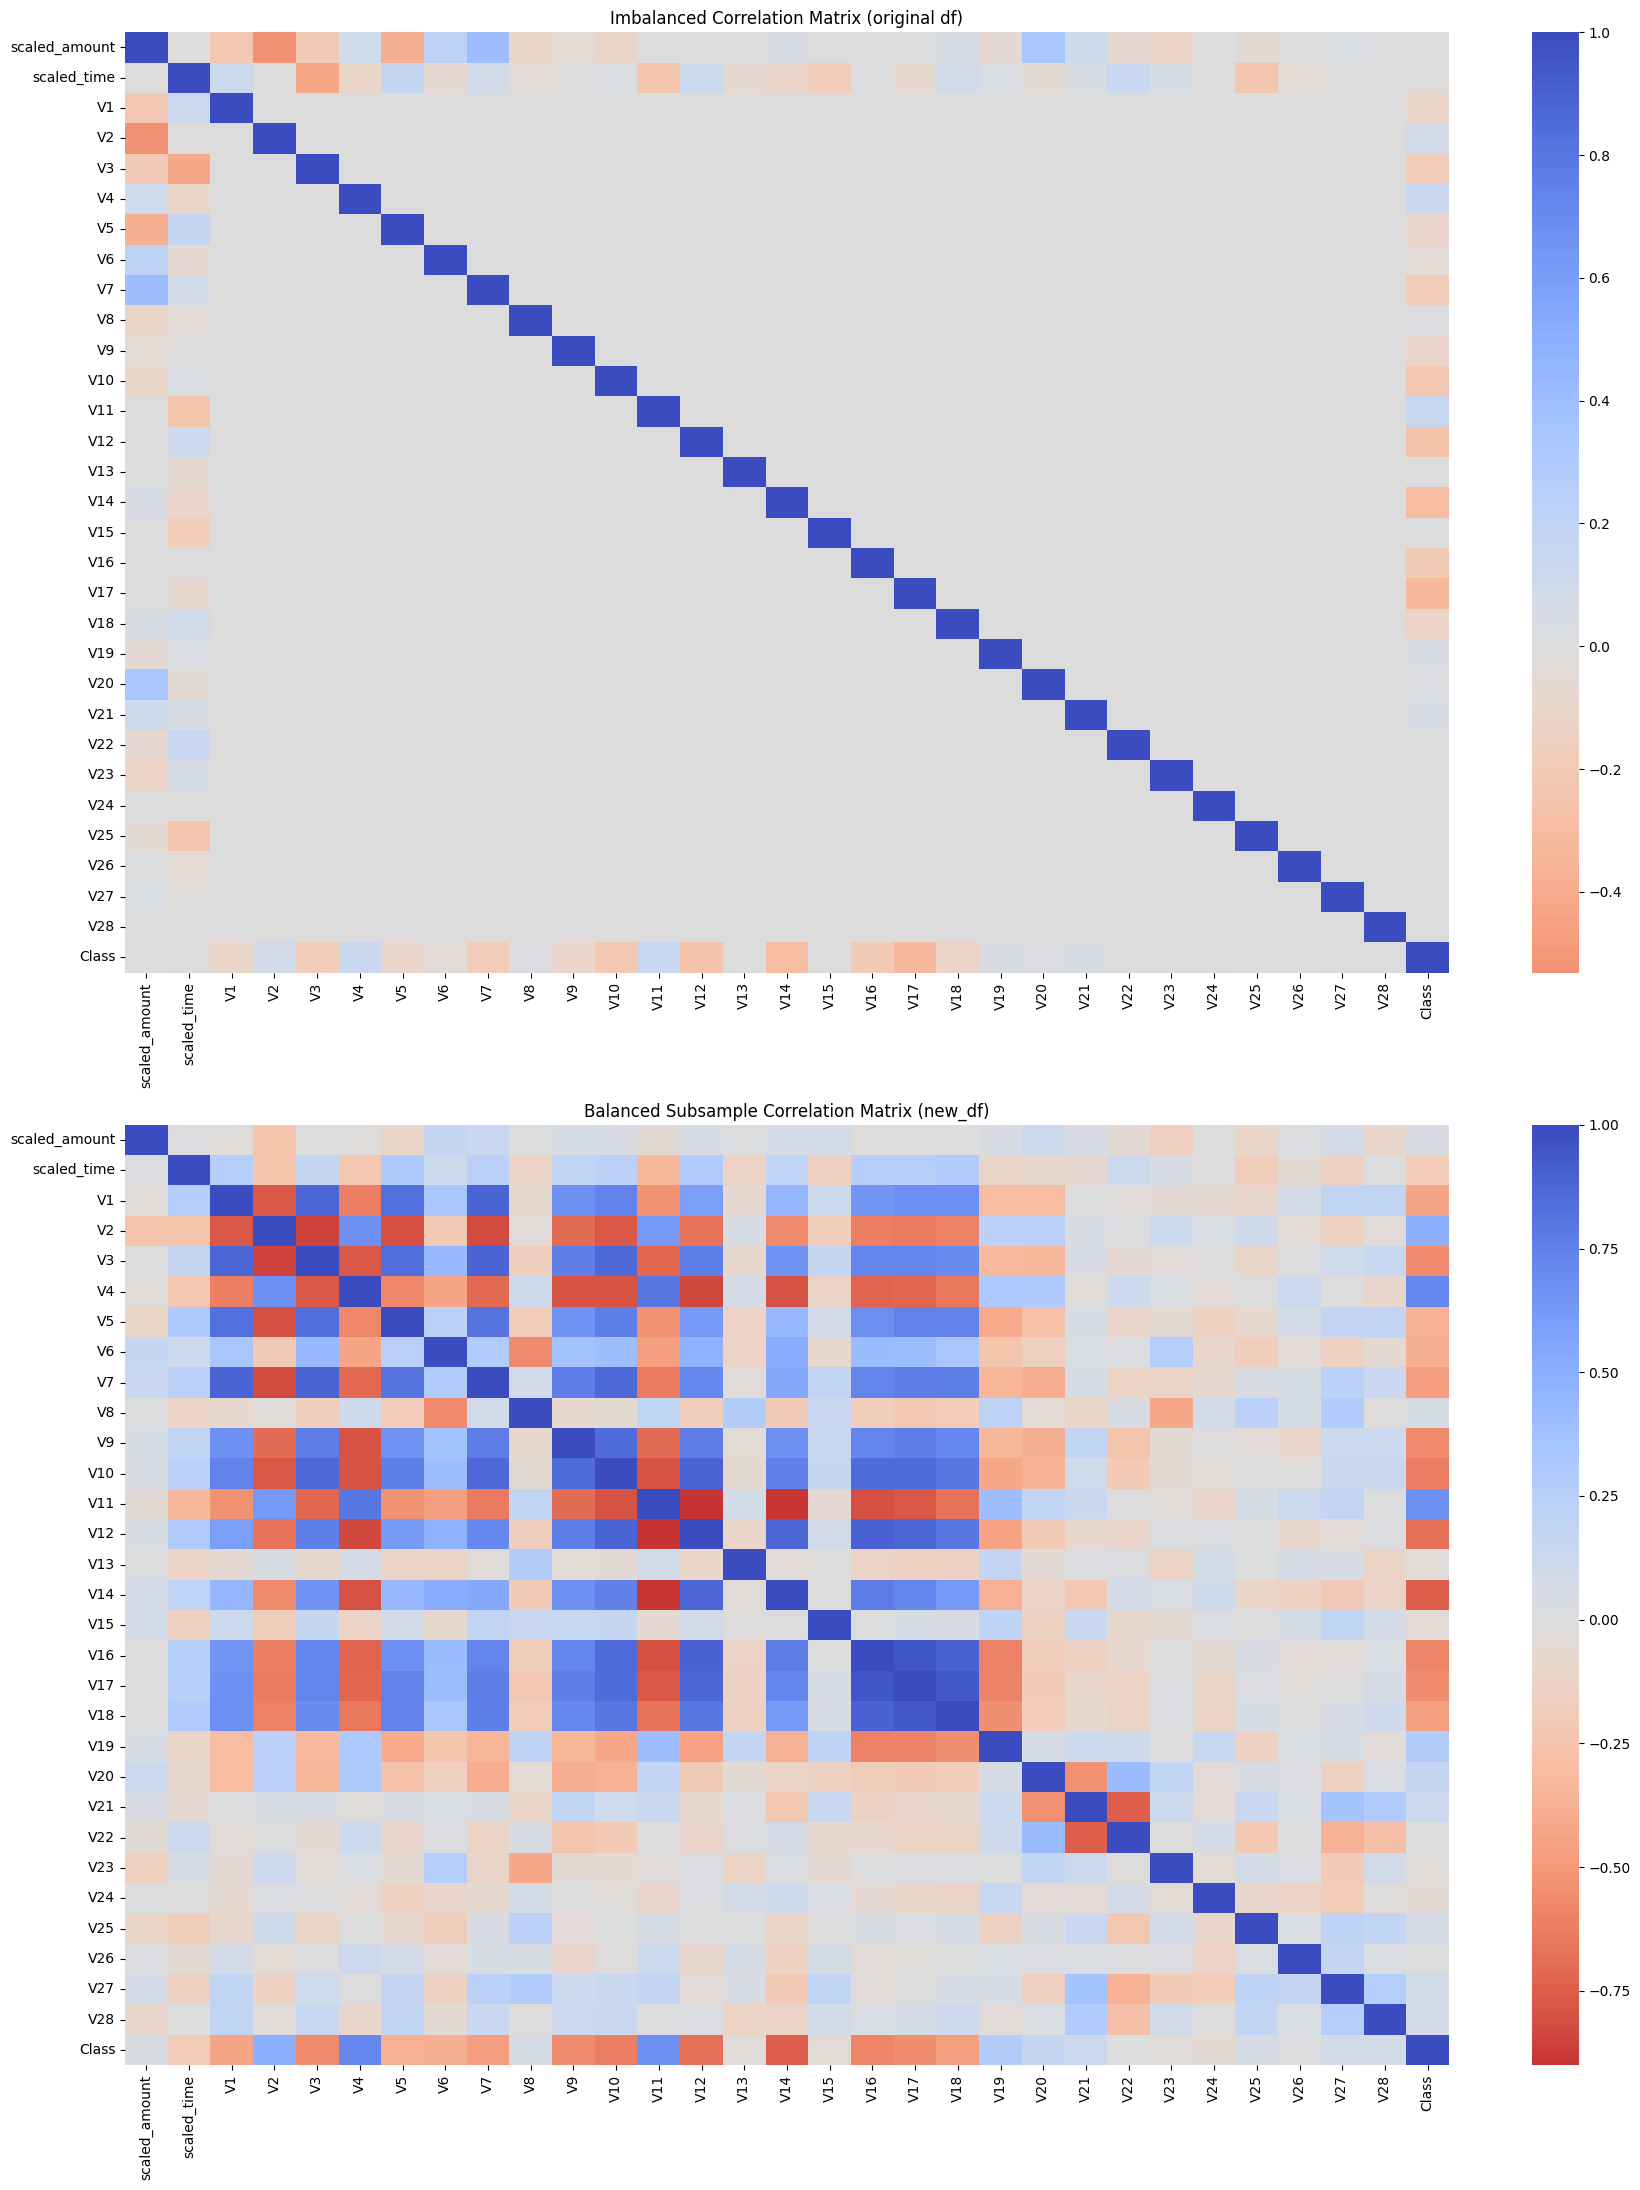

In [48]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 22))

corr1 = df_shuf.corr(numeric_only=True)
corr2 = new_df.corr(numeric_only=True)

sns.heatmap(corr1, cmap="coolwarm_r", center=0, ax=ax1)
ax1.set_title("Imbalanced Correlation Matrix (original df)")

sns.heatmap(corr2, cmap="coolwarm_r", center=0, ax=ax2)
ax2.set_title("Balanced Subsample Correlation Matrix (new_df)")

plt.tight_layout()
plt.show()

In [44]:
corr_with_class = (
    new_df.corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values()
)

print("Most negative:\n", corr_with_class.head(10))
print("\nMost positive:\n", corr_with_class.tail(10))

Most negative:
 V14   -0.751612
V12   -0.683124
V10   -0.622988
V16   -0.593553
V3    -0.566039
V9    -0.566038
V17   -0.558124
V7    -0.475051
V18   -0.465533
V1    -0.437301
Name: Class, dtype: float64

Most positive:
 V25    0.063035
V8     0.064746
V28    0.072763
V27    0.092572
V21    0.117184
V20    0.155772
V19    0.274071
V2     0.500581
V11    0.677234
V4     0.721081
Name: Class, dtype: float64


In [53]:
corr_with_class = (
    df_shuf.corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values()
)

print("Most negative:\n", corr_with_class.head(10))
print("\nMost positive:\n", corr_with_class.tail(10))

Most negative:
 V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
Name: Class, dtype: float64

Most positive:
 scaled_amount    0.005632
V28              0.009536
V27              0.017580
V8               0.019875
V20              0.020090
V19              0.034783
V21              0.040413
V2               0.091289
V4               0.133447
V11              0.154876
Name: Class, dtype: float64


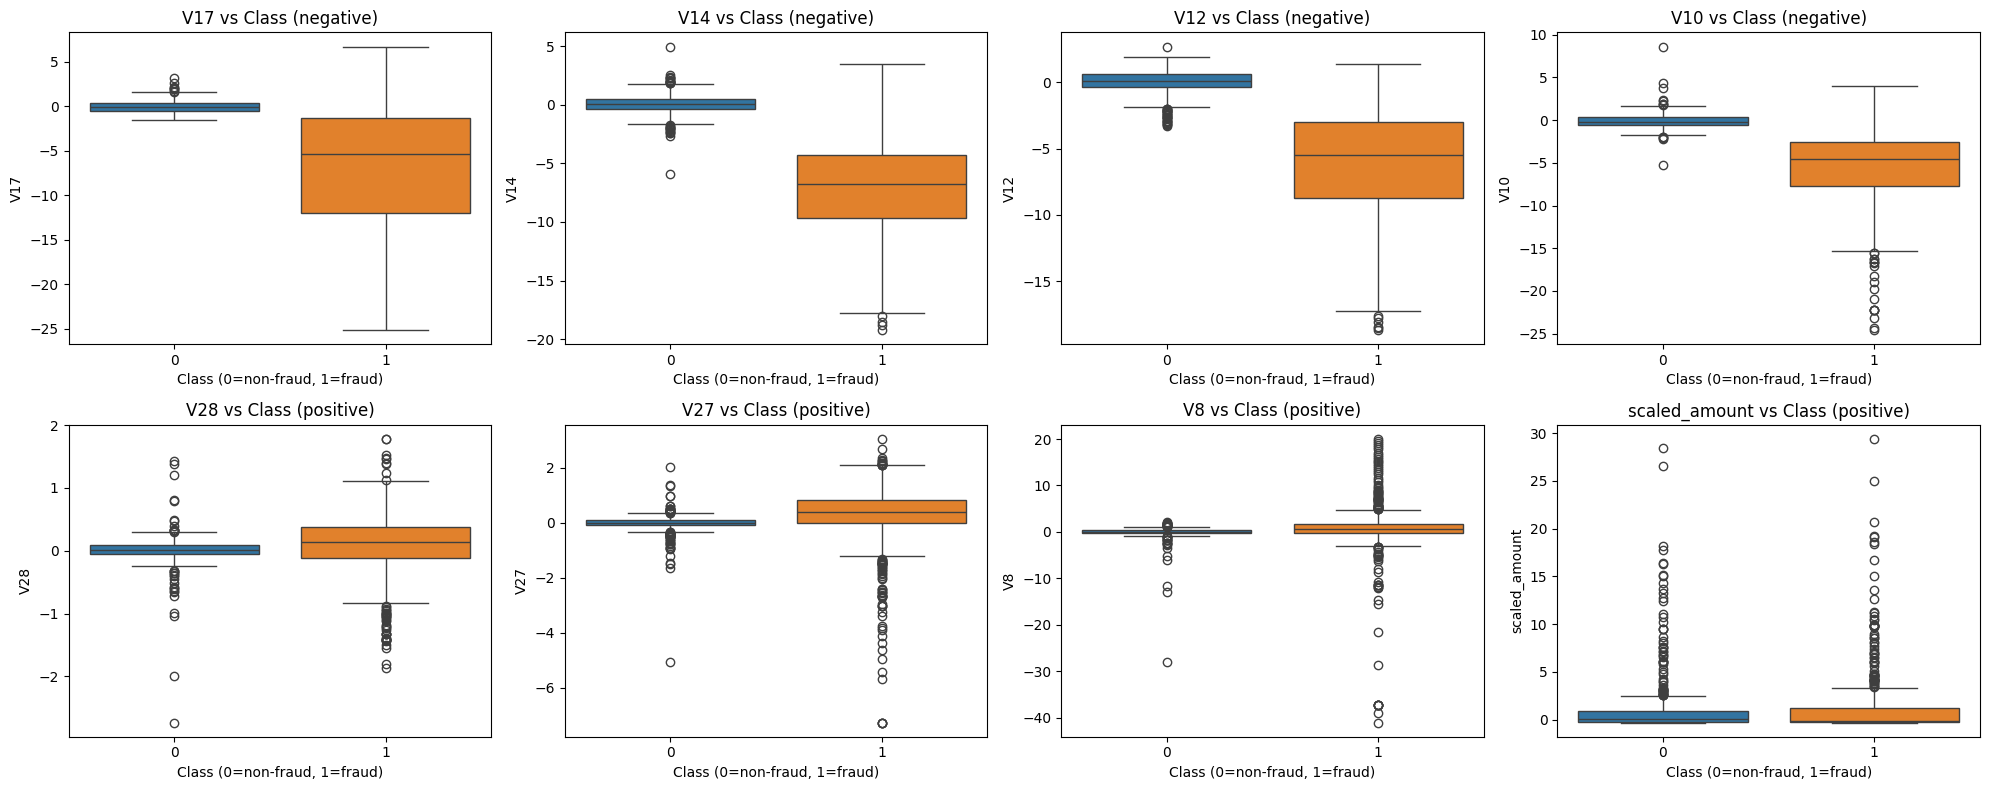

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

MOST_NEGATIVE = ['V17', 'V14', 'V12', 'V10']
MOST_POSITIVE = ['V28', 'V27', 'V8', 'scaled_amount']

# Two colors: Class 0 and Class 1
colors = {0: "#1f77b4", 1: "#ff7f0e"}  # blue, orange

def plot_class_boxplots(df, neg_features, pos_features, palette=colors):
    """
    Draws boxplots of each feature vs Class (0/1) with Seaborn v0.14+ compatible palette usage.
    Top row: neg_features
    Bottom row: pos_features
    """
    if "Class" not in df.columns:
        raise ValueError("DataFrame must contain a 'Class' column (0/1).")

    # Ensure Class is clean ints (helps palette mapping)
    df = df.copy()
    df["Class"] = df["Class"].astype(int)

    # Keep only existing features
    neg = [c for c in neg_features if c in df.columns]
    pos = [c for c in pos_features if c in df.columns]

    missing_feats = [c for c in (neg_features + pos_features) if c not in df.columns]
    if missing_feats:
        print(f"Warning: skipping missing features: {missing_feats}")

    ncols = max(len(neg), len(pos))
    fig, axes = plt.subplots(nrows=2, ncols=ncols, figsize=(5 * ncols, 8), squeeze=False)

    def _box(ax, feat, title):
        sns.boxplot(
            data=df,
            x="Class",
            y=feat,
            hue="Class",          # <-- fixes the FutureWarning
            palette=palette,
            ax=ax
        )
        # Remove redundant legend (same as x-axis)
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        ax.set_title(title)
        ax.set_xlabel("Class (0=non-fraud, 1=fraud)")

    # Row 1: negative
    for i in range(ncols):
        ax = axes[0, i]
        if i < len(neg):
            feat = neg[i]
            _box(ax, feat, f"{feat} vs Class (negative)")
        else:
            ax.axis("off")

    # Row 2: positive
    for i in range(ncols):
        ax = axes[1, i]
        if i < len(pos):
            feat = pos[i]
            _box(ax, feat, f"{feat} vs Class (positive)")
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

# Usage:
plot_class_boxplots(new_df, MOST_NEGATIVE, MOST_POSITIVE)


Removing extreme outliers using IQR can help a little bit, but it is risky, so I didn't implement removing extreme outliers. For an experiment, It is recommended to try out.

t-SNE (3D) took 25.41 s
PCA (3D) took 0.10 s
TruncatedSVD (3D) took 0.02 s


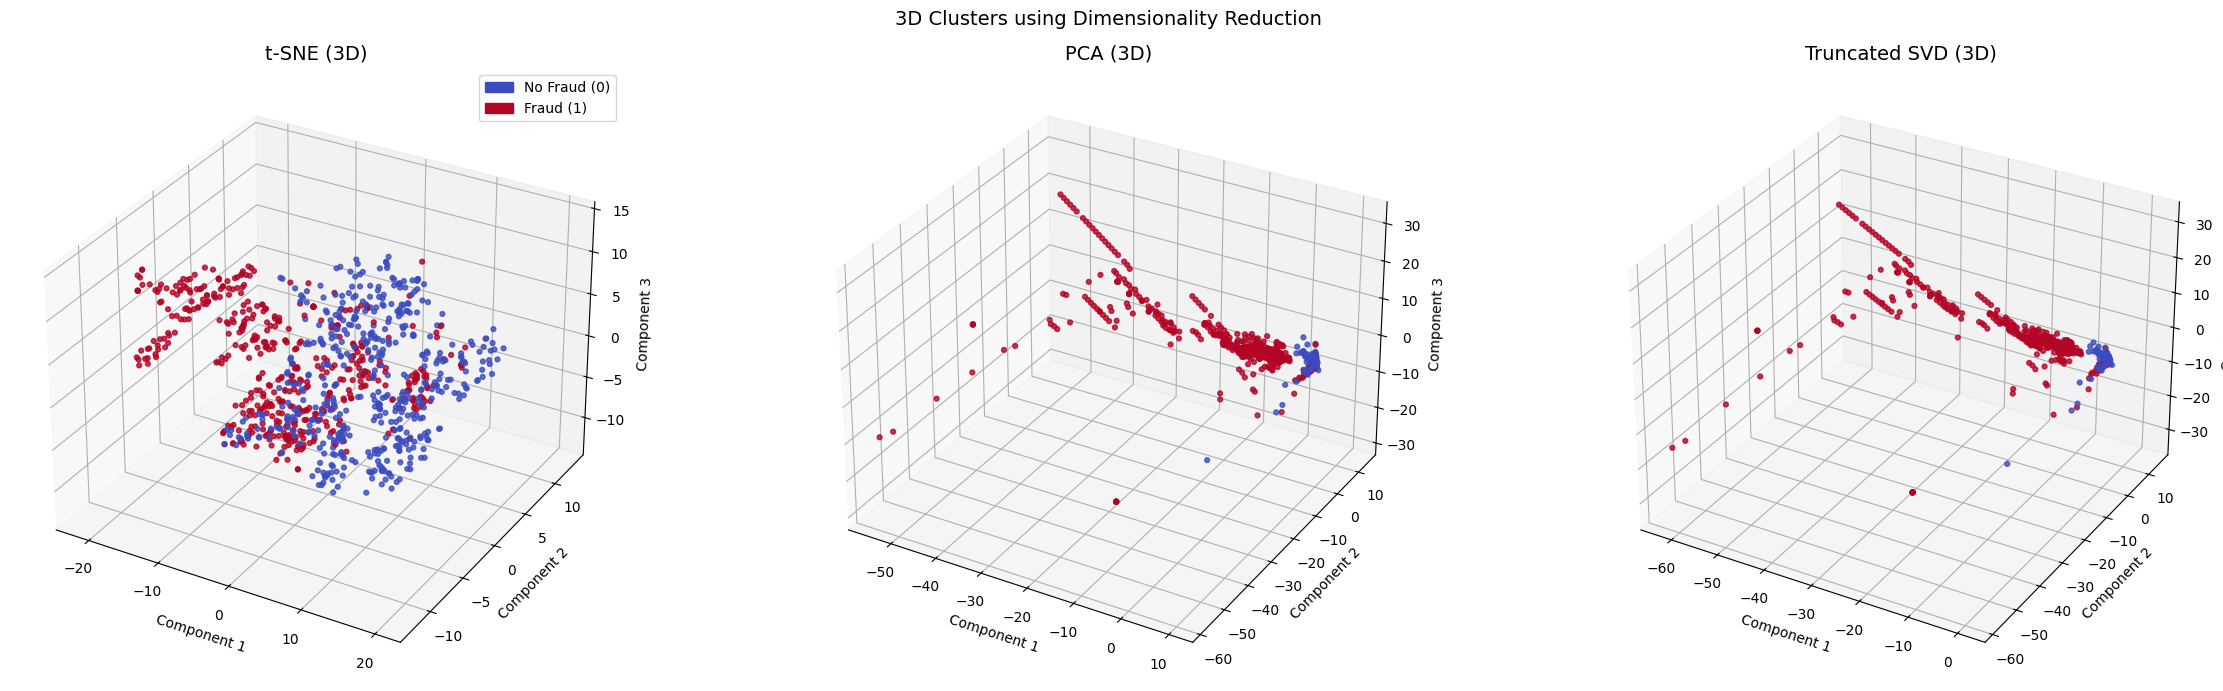

In [61]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

# -------------------------
# Data (balanced/undersampled)
# -------------------------
X = new_df.drop("Class", axis=1).values
y = new_df["Class"].astype(int).values

# Optional: if you ever run this on a much bigger df, subsample for speed:
# n = min(len(y), 3000)
# idx = np.random.RandomState(42).choice(len(y), size=n, replace=False)
# X, y = X[idx], y[idx]

# -------------------------
# 3D Dimensionality reduction
# -------------------------
t0 = time.time()
X_tsne_3d = TSNE(
    n_components=3,
    random_state=42,
    init="pca",
    learning_rate="auto",
    perplexity=30,  # must be < n_samples
).fit_transform(X)
print(f"t-SNE (3D) took {time.time() - t0:.2f} s")

t0 = time.time()
X_pca_3d = PCA(n_components=3, svd_solver="randomized", random_state=42).fit_transform(X)
print(f"PCA (3D) took {time.time() - t0:.2f} s")

t0 = time.time()
X_svd_3d = TruncatedSVD(n_components=3, algorithm="randomized", random_state=42).fit_transform(X)
print(f"TruncatedSVD (3D) took {time.time() - t0:.2f} s")

# -------------------------
# Plotting (3D)
# -------------------------
fig = plt.figure(figsize=(24, 7))
fig.suptitle("3D Clusters using Dimensionality Reduction", fontsize=14)

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax3 = fig.add_subplot(1, 3, 3, projection="3d")

def plot3d(ax, X3d, y, title):
    ax.scatter(
        X3d[:, 0], X3d[:, 1], X3d[:, 2],
        c=y, cmap="coolwarm", s=12, alpha=0.8
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.set_zlabel("Component 3")
    ax.grid(True)

plot3d(ax1, X_tsne_3d, y, "t-SNE (3D)")
plot3d(ax2, X_pca_3d,  y, "PCA (3D)")
plot3d(ax3, X_svd_3d,  y, "Truncated SVD (3D)")

# Simple legend matching the colormap endpoints
no_fraud_color = plt.cm.coolwarm(0.0)
fraud_color = plt.cm.coolwarm(1.0)
legend_handles = [
    Patch(color=no_fraud_color, label="No Fraud (0)"),
    Patch(color=fraud_color, label="Fraud (1)"),
]
ax1.legend(handles=legend_handles, loc="best")

plt.tight_layout()
plt.show()
